In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [26]:
FILES = {
    "Branch_1": "branch1_predictive_dataset.xlsx",
    "Branch_2": "branch2_predictive_dataset.xlsx",
    "Branch_3": "branch3_predictive_dataset.xlsx",
}

HORIZON_DAYS = 7
THRESHOLD = 0.50

In [27]:
def get_risk_level(p):
    if p < 0.30:
        return "Low"
    elif p < 0.60:
        return "Medium"
    elif p < 0.80:
        return "High"
    else:
        return "Critical"


def get_recommendation(risk):
    if risk == "Low":
        return "No action needed"
    elif risk == "Medium":
        return "Monitor closely"
    elif risk == "High":
        return "Schedule maintenance"
    else:
        return "Immediate intervention required"

In [28]:
def prepare_branch_data(df, horizon_days=7):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

    # Time features
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear

    # Counter increment
    df["counter_diff"] = df.groupby("serial_number")["counter"].diff().fillna(0)

    # Rolling features from past only
    for col in ["temperature", "load", "vibration", "health_score", "counter_diff"]:
        for w in [3, 7, 14]:
            df[f"{col}_mean_{w}"] = (
                df.groupby("serial_number")[col]
                .transform(lambda s: s.shift(1).rolling(w).mean())
            )
            df[f"{col}_std_{w}"] = (
                df.groupby("serial_number")[col]
                .transform(lambda s: s.shift(1).rolling(w).std())
            )

    # Future target: will failure happen in next 7 days
    df["target_future_failure"] = 0

    for serial, group in df.groupby("serial_number"):
        idx = group.index.tolist()
        y = group["failure_flag"].values

        future_target = np.zeros(len(group), dtype=int)

        for i in range(len(group)):
            end_idx = min(i + horizon_days + 1, len(group))
            future_window = y[i + 1:end_idx]
            if len(future_window) > 0 and np.max(future_window) == 1:
                future_target[i] = 1

        df.loc[idx, "target_future_failure"] = future_target

    # Drop rows with NaN caused by rolling calculations
    df = df.dropna().reset_index(drop=True)

    numeric_features = [
        "health_score",
        "counter",
        "temperature",
        "load",
        "vibration",
        "day_of_week",
        "month",
        "day_of_year",
        "counter_diff",
    ] + [
        col for col in df.columns
        if ("_mean_" in col or "_std_" in col)
    ]

    categorical_features = [
        "scanner_model",
        "maintenance_performed",
        "spare_parts",
        "technician",
    ]

    X = df[numeric_features + categorical_features]
    y = df["target_future_failure"]

    return df, X, y, numeric_features, categorical_features

In [30]:
def evaluate_models(df, X, y, numeric_features, categorical_features):
    split_index = int(len(df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    model_configs = {
        "Logistic Regression": {
            "preprocessor": ColumnTransformer(
                transformers=[
                    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                    ("num", StandardScaler(), numeric_features),
                ]
            ),
            "model": LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ),
        },
        "Random Forest": {
            "preprocessor": ColumnTransformer(
                transformers=[
                    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                    ("num", "passthrough", numeric_features),
                ]
            ),
            "model": RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                min_samples_leaf=2,
                n_jobs=-1
            ),
        },
        "Gradient Boosting": {
            "preprocessor": ColumnTransformer(
                transformers=[
                    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                    ("num", "passthrough", numeric_features),
                ]
            ),
            "model": GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ),
        },
    }

    results = []
    trained_pipelines = {}

    for model_name, cfg in model_configs.items():
        pipeline = Pipeline([
            ("preprocessor", cfg["preprocessor"]),
            ("model", cfg["model"])
        ])

        pipeline.fit(X_train, y_train)
        proba = pipeline.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, proba)
        pr_auc = average_precision_score(y_test, proba)

        results.append({
            "model": model_name,
            "roc_auc": auc,
            "pr_auc": pr_auc
        })

        trained_pipelines[model_name] = pipeline

    results_df = pd.DataFrame(results).sort_values(
        by="pr_auc", ascending=False
    ).reset_index(drop=True)

    best_model_name = results_df.loc[0, "model"]
    best_pipeline = trained_pipelines[best_model_name]

    return best_pipeline, best_model_name, results_df, X_train, X_test, y_train, y_test

In [31]:
def extract_feature_importance(model_pipeline):
    model = model_pipeline.named_steps["model"]
    preprocessor = model_pipeline.named_steps["preprocessor"]
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
    elif hasattr(model, "coef_"):
        importance_values = np.abs(model.coef_[0])
    else:
        return pd.DataFrame(columns=["feature", "importance"])

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    return feature_importance_df

In [32]:
def predict_latest_scanners(df, X, model):
    latest_idx = df.groupby("serial_number")["date"].idxmax()
    latest_rows = df.loc[latest_idx].copy()
    X_latest = X.loc[latest_idx].copy()

    proba = model.predict_proba(X_latest)[:, 1]
    latest_rows["failure_probability_next_7d"] = proba
    latest_rows["risk_level"] = latest_rows["failure_probability_next_7d"].apply(get_risk_level)
    latest_rows["recommendation"] = latest_rows["risk_level"].apply(get_recommendation)

    latest_rows = latest_rows.sort_values(
        "failure_probability_next_7d", ascending=False
    ).reset_index(drop=True)

    return latest_rows[
        [
            "serial_number",
            "scanner_model",
            "date",
            "failure_probability_next_7d",
            "risk_level",
            "recommendation",
        ]
    ]

In [33]:
def calculate_classification_metrics(model, X_test, y_test, threshold=0.50):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics_df = pd.DataFrame([{
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "threshold": threshold
    }])

    return metrics_df, y_pred, y_proba

In [34]:
def plot_confusion_matrix(y_test, y_pred, branch_name):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Failure", "Failure"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{branch_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_test, y_proba, branch_name):
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{branch_name} - ROC Curve")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_precision_recall_curve(y_test, y_proba, branch_name):
    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{branch_name} - Precision-Recall Curve")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_top_features(feature_df, branch_name, top_n=10):
    if feature_df.empty:
        print(f"No feature importance available for {branch_name}")
        return

    top_features = feature_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.title(f"{branch_name} - Top {top_n} Important Features")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

Processing Branch_1 ...
Best Model: Random Forest

Model Comparison:


,model,roc_auc,pr_auc
0,Random Forest,0.99375,0.987085
1,Gradient Boosting,0.99219,0.985738
2,Logistic Regression,0.99127,0.982551



Classification Metrics:


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,threshold
0,0.952652,0.960396,0.884498,0.920886,0.99375,0.987085,0.5



Top 5 High-Risk Scanners:


,serial_number,scanner_model,date,failure_probability_next_7d,risk_level,recommendation
0,55100007,Fujitsu 7600,2024-12-31,0.301368,Medium,Monitor closely
1,55100010,Kodak i4650,2024-12-31,0.301327,Medium,Monitor closely
2,55100015,Kodak i4650,2024-12-31,0.288708,Low,No action needed
3,55100006,Kodak i4250,2024-12-31,0.268559,Low,No action needed
4,55100001,Kodak i4650,2024-12-31,0.265236,Low,No action needed



Classification Report:
              precision    recall  f1-score   support

  No Failure       0.95      0.98      0.97       727
     Failure       0.96      0.88      0.92       329

    accuracy                           0.95      1056
   macro avg       0.95      0.93      0.94      1056
weighted avg       0.95      0.95      0.95      1056



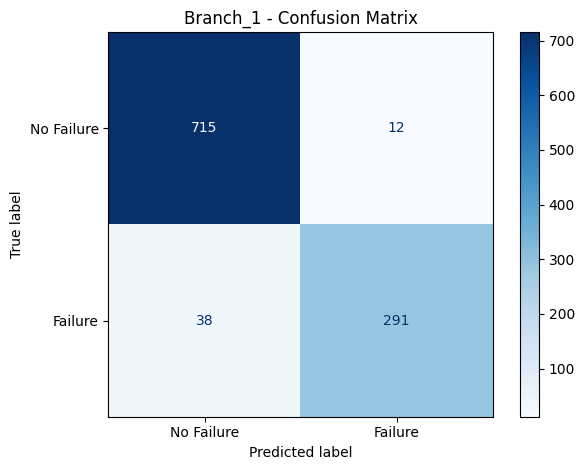

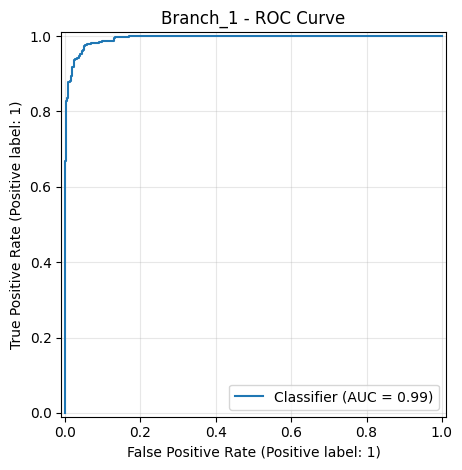

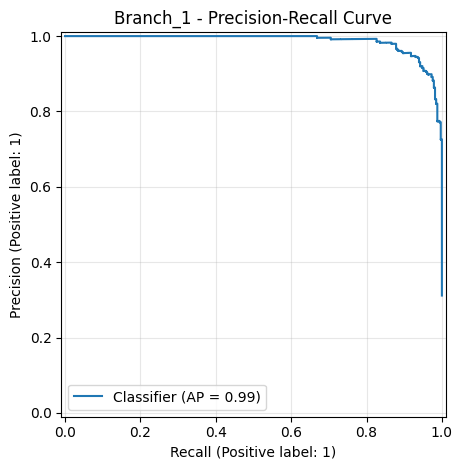

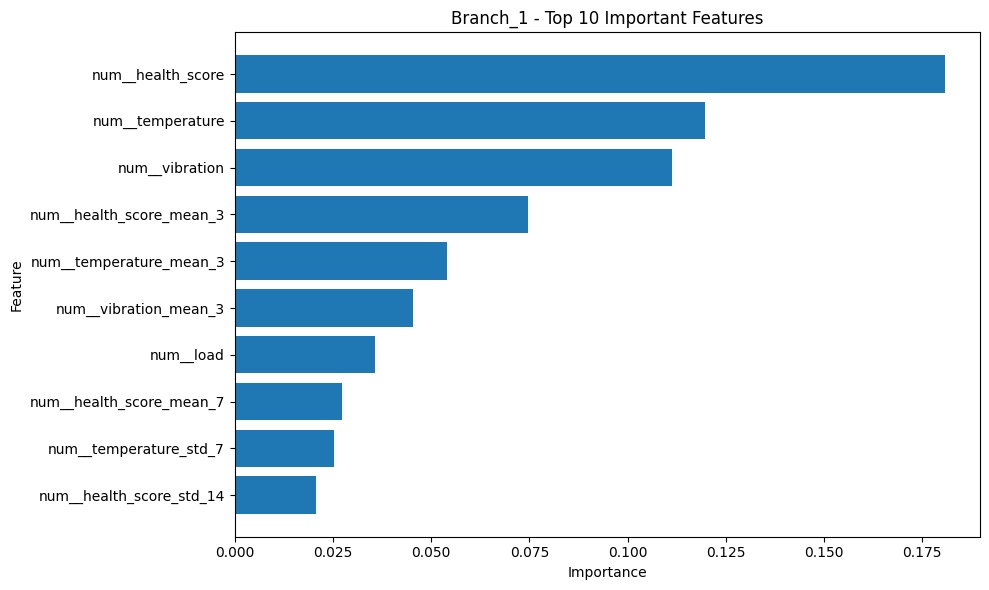

Processing Branch_2 ...
Best Model: Random Forest

Model Comparison:


,model,roc_auc,pr_auc
0,Random Forest,0.993562,0.987887
1,Gradient Boosting,0.992877,0.986143
2,Logistic Regression,0.990136,0.980368



Classification Metrics:


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,threshold
0,0.953125,0.925311,0.936975,0.931106,0.993562,0.987887,0.5



Top 5 High-Risk Scanners:


,serial_number,scanner_model,date,failure_probability_next_7d,risk_level,recommendation
0,55200009,Kodak i4650,2024-12-31,0.693839,High,Schedule maintenance
1,55200003,Kodak i4250,2024-12-31,0.525910,Medium,Monitor closely
2,55200006,Fujitsu 7600,2024-12-31,0.422092,Medium,Monitor closely
3,55200002,Kodak i4250,2024-12-31,0.028164,Low,No action needed
4,55200004,Kodak i4650,2024-12-31,0.013255,Low,No action needed



Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.96      0.96       466
     Failure       0.93      0.94      0.93       238

    accuracy                           0.95       704
   macro avg       0.95      0.95      0.95       704
weighted avg       0.95      0.95      0.95       704



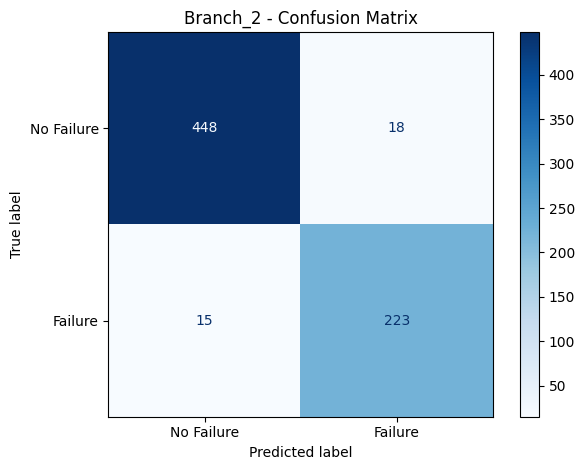

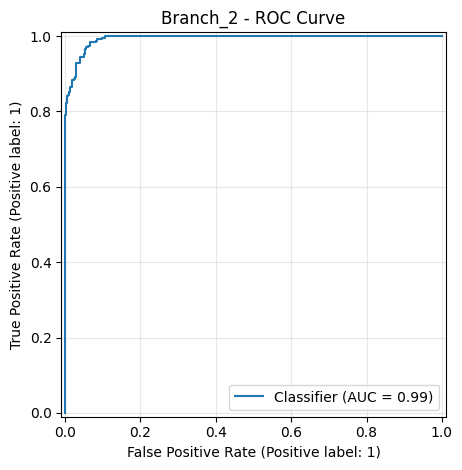

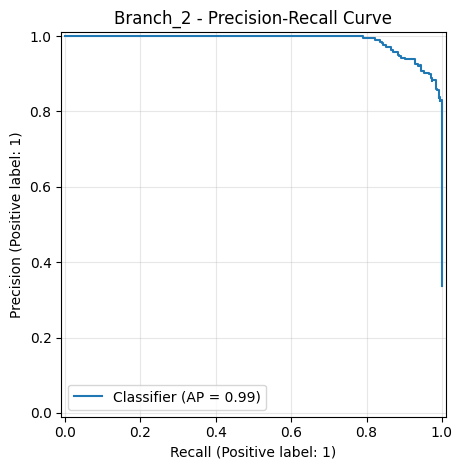

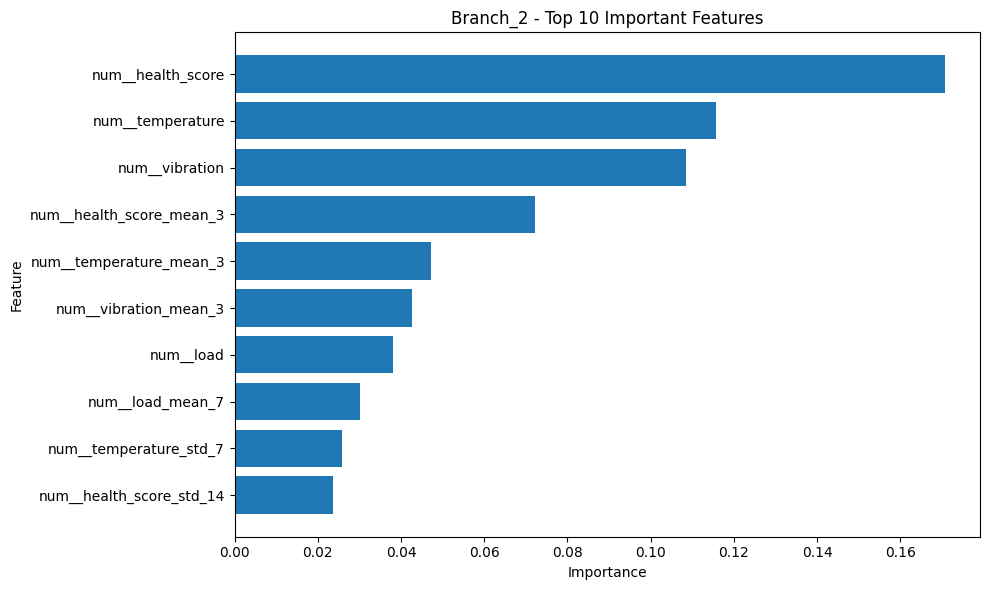

Processing Branch_3 ...
Best Model: Gradient Boosting

Model Comparison:


,model,roc_auc,pr_auc
0,Gradient Boosting,0.986109,0.965767
1,Logistic Regression,0.984847,0.961718
2,Random Forest,0.984194,0.957176



Classification Metrics:


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,threshold
0,0.919527,0.792157,0.930876,0.855932,0.986109,0.965767,0.5



Top 5 High-Risk Scanners:


,serial_number,scanner_model,date,failure_probability_next_7d,risk_level,recommendation
0,55300011,Kodak i5200,2024-12-31,0.761039,High,Schedule maintenance
1,55300010,Kodak i4650,2024-12-31,0.694802,High,Schedule maintenance
2,55300012,Kodak i3200,2024-12-31,0.632254,High,Schedule maintenance
3,55300008,Kodak i4250,2024-12-31,0.198478,Low,No action needed
4,55300005,Kodak i4250,2024-12-31,0.057844,Low,No action needed



Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.92      0.94       628
     Failure       0.79      0.93      0.86       217

    accuracy                           0.92       845
   macro avg       0.88      0.92      0.90       845
weighted avg       0.93      0.92      0.92       845



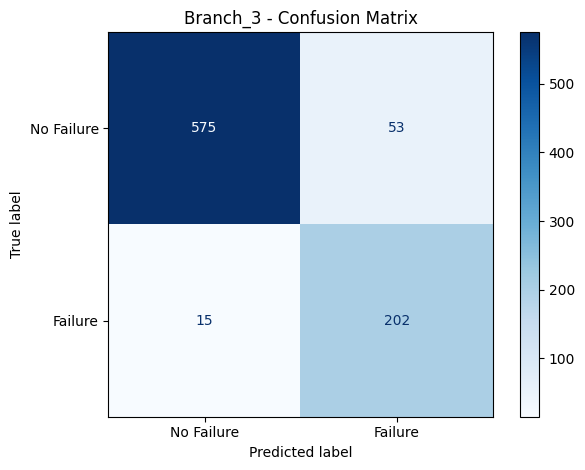

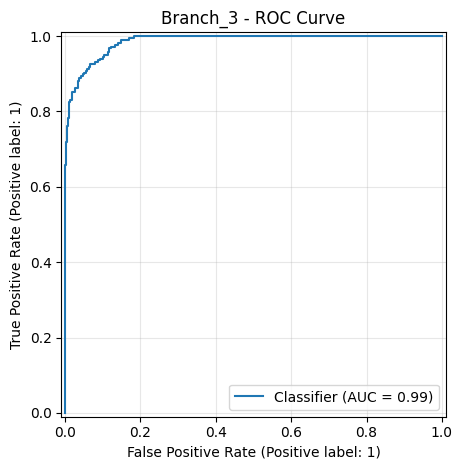

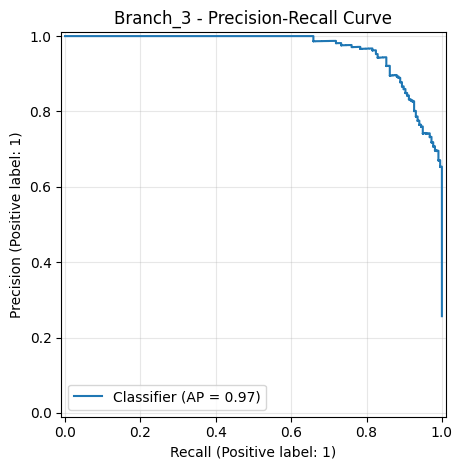

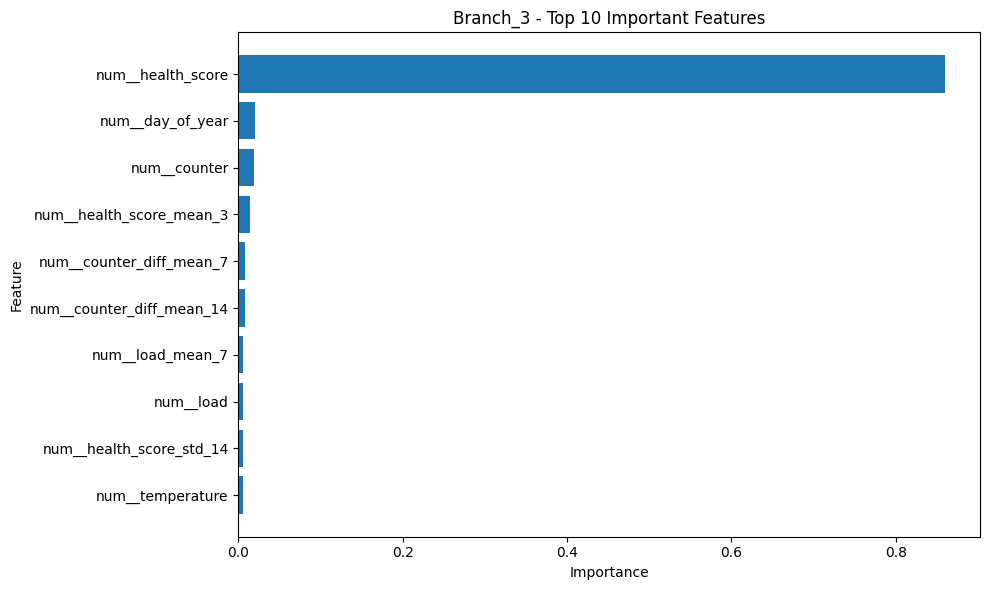

In [35]:
all_results = {}

for branch_name, file_name in FILES.items():
    print("=" * 100)
    print(f"Processing {branch_name} ...")

    df = pd.read_excel(file_name)

    df_ready, X, y, numeric_features, categorical_features = prepare_branch_data(
        df, horizon_days=HORIZON_DAYS
    )

    best_model, best_model_name, comparison_df, X_train, X_test, y_train, y_test = evaluate_models(
        df_ready, X, y, numeric_features, categorical_features
    )

    feature_importance_df = extract_feature_importance(best_model)
    latest_predictions = predict_latest_scanners(df_ready, X, best_model)

    metrics_df, y_pred, y_proba = calculate_classification_metrics(
        best_model, X_test, y_test, threshold=THRESHOLD
    )

    all_results[branch_name] = {
        "model": best_model,
        "best_model_name": best_model_name,
        "comparison_df": comparison_df,
        "feature_importance_df": feature_importance_df,
        "latest_predictions": latest_predictions,
        "metrics_df": metrics_df,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    print(f"Best Model: {best_model_name}")

    print("\nModel Comparison:")
    display(comparison_df)

    print("\nClassification Metrics:")
    display(metrics_df)

    print("\nTop 5 High-Risk Scanners:")
    display(latest_predictions.head(5))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"], zero_division=0))

    plot_confusion_matrix(y_test, y_pred, branch_name)
    plot_roc_curve(y_test, y_proba, branch_name)
    plot_precision_recall_curve(y_test, y_proba, branch_name)
    plot_top_features(feature_importance_df, branch_name, top_n=10)

In [36]:
for branch_name, data in all_results.items():
    output_file = f"{branch_name.lower()}_predictions.xlsx"

    with pd.ExcelWriter(output_file) as writer:
        data["latest_predictions"].to_excel(writer, sheet_name="Predictions", index=False)
        data["comparison_df"].to_excel(writer, sheet_name="Model_Comparison", index=False)
        data["feature_importance_df"].head(20).to_excel(writer, sheet_name="Top_Features", index=False)
        data["metrics_df"].to_excel(writer, sheet_name="Metrics", index=False)

    print(f"Saved: {output_file}")

Saved: branch_1_predictions.xlsx
Saved: branch_2_predictions.xlsx
Saved: branch_3_predictions.xlsx


In [37]:
summary_rows = []

for branch_name, data in all_results.items():
    row = {
        "branch": branch_name,
        "best_model": data["best_model_name"],
        "accuracy": data["metrics_df"].loc[0, "accuracy"],
        "precision": data["metrics_df"].loc[0, "precision"],
        "recall": data["metrics_df"].loc[0, "recall"],
        "f1_score": data["metrics_df"].loc[0, "f1_score"],
        "roc_auc": data["metrics_df"].loc[0, "roc_auc"],
        "pr_auc": data["metrics_df"].loc[0, "pr_auc"],
        "threshold": data["metrics_df"].loc[0, "threshold"]
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,branch,best_model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,threshold
0,Branch_1,Random Forest,0.952652,0.960396,0.884498,0.920886,0.993750,0.987085,0.5
1,Branch_2,Random Forest,0.953125,0.925311,0.936975,0.931106,0.993562,0.987887,0.5
2,Branch_3,Gradient Boosting,0.919527,0.792157,0.930876,0.855932,0.986109,0.965767,0.5
